In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
import warnings
import os

SEED = 42

In [33]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('ggplot')
sns.set_palette("husl")

# Define Column Names for NSL-KDD (Standard List)
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]

In [34]:
candidate_pairs = [
    ('./data/KDDTrain+.txt', './data/KDDTest+.txt'),
    ('./Python/data/KDDTrain+.txt', './Python/data/KDDTest+.txt'),
    ('data/KDDTrain+.txt', 'data/KDDTest+.txt'),
    ('Python/data/KDDTrain+.txt', 'Python/data/KDDTest+.txt')
]

df_train, df_test = None, None
for train_path, test_path in candidate_pairs:
    if os.path.exists(train_path) and os.path.exists(test_path):
        df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
        df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
        print(f"Loaded train from: {train_path}")
        print(f"Loaded test from : {test_path}")
        break

if df_train is None or df_test is None:
    raise FileNotFoundError("KDDTrain+.txt and KDDTest+.txt were not found in expected folders.")

print(f"Training Data Shape: {df_train.shape}")
print(f"Test Data Shape: {df_test.shape}")

Loaded train from: ./Python/data/KDDTrain+.txt
Loaded test from : ./Python/data/KDDTest+.txt
Training Data Shape: (125973, 43)
Test Data Shape: (22544, 43)


In [35]:

# Mapping Dictionary
attack_mapping = {
    'normal': 'normal',
    
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L', 'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R', 'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R'
}

# Apply mapping
df_train['attack_class'] = df_train['label'].map(lambda x: attack_mapping.get(x, 'other'))
df_test['attack_class'] = df_test['label'].map(lambda x: attack_mapping.get(x, 'other'))

print("Training Class Distribution:")
print(df_train['attack_class'].value_counts())


Training Class Distribution:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [36]:
#Definign feature Groups

categorical_features = ['protocol_type','service','flag']
binary_features = ['land','logged_in','is_host_login','is_guest_login']
#All the other numerical values

numerical_features = [col for col in COL_NAMES if col not in categorical_features + binary_features +['label','difficulty_level']]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Binary Features: {len(binary_features)}")
print(f"Numerical Features: {len(numerical_features)}")

print(df_train.isnull())


Categorical Features: 3
Binary Features: 4
Numerical Features: 34
        duration  protocol_type  service   flag  src_bytes  dst_bytes   land  \
0          False          False    False  False      False      False  False   
1          False          False    False  False      False      False  False   
2          False          False    False  False      False      False  False   
3          False          False    False  False      False      False  False   
4          False          False    False  False      False      False  False   
...          ...            ...      ...    ...        ...        ...    ...   
125968     False          False    False  False      False      False  False   
125969     False          False    False  False      False      False  False   
125970     False          False    False  False      False      False  False   
125971     False          False    False  False      False      False  False   
125972     False          False    False  False      F

In [37]:
def clean_outliers_isolation_forest(df,contamination = 0.01):
    iso_df  = df[numerical_features].copy()

    clf = IsolationForest(max_samples='auto',contamination = contamination, random_state = 42)

    outliers = clf.fit_predict(iso_df)

    n_outliers = (outliers == -1).sum()
    print(f"Identifies {n_outliers} Outlilers using the Isolation forest")

    return outliers
df_train['is_outlier'] = clean_outliers_isolation_forest(df_train)


Identifies 1256 Outlilers using the Isolation forest


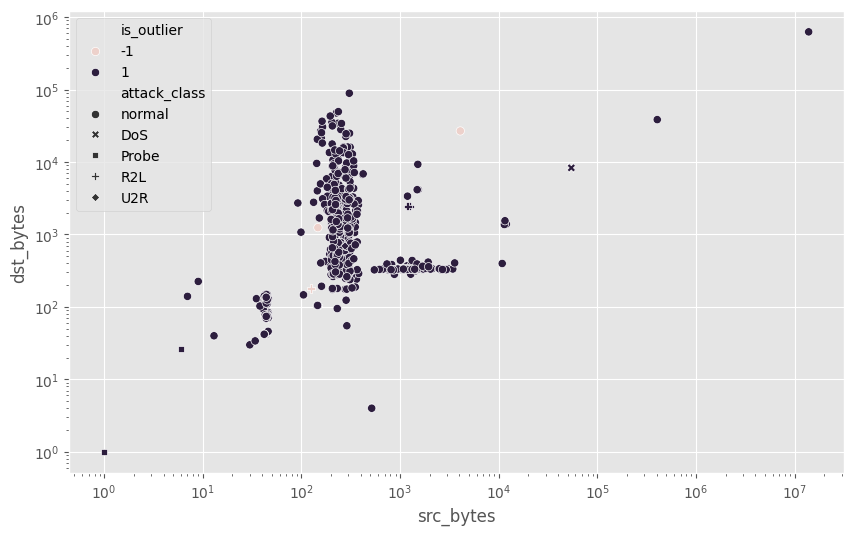

In [38]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_train[::100], x = 'src_bytes', y = 'dst_bytes', hue='is_outlier', style='attack_class')
plt.xscale('log')
plt.yscale('log')
plt.show()

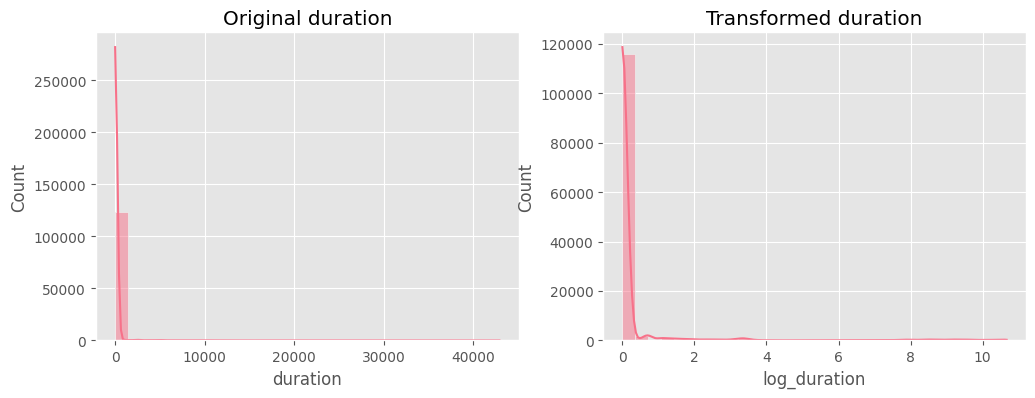

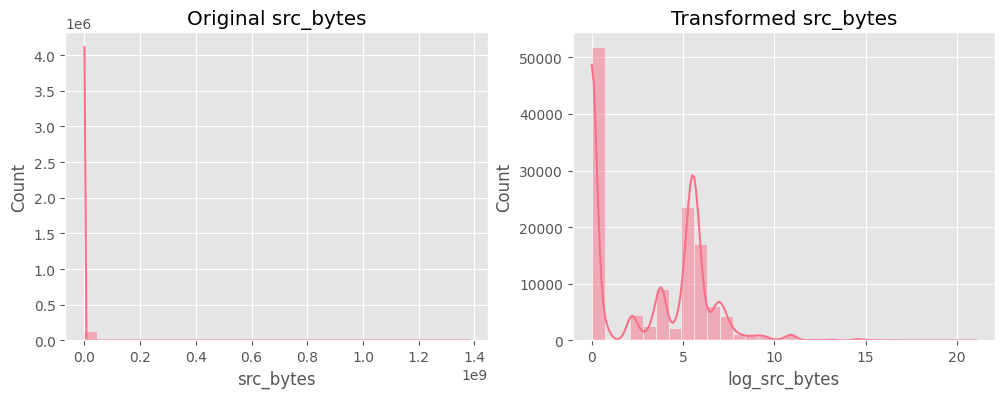

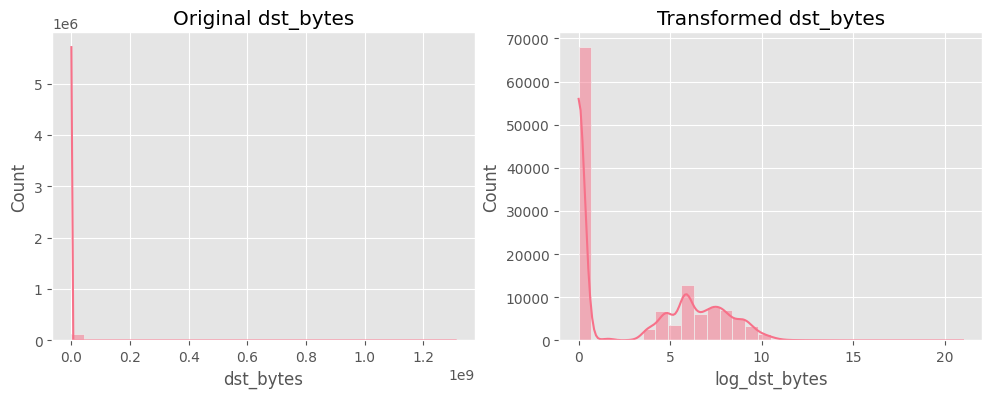

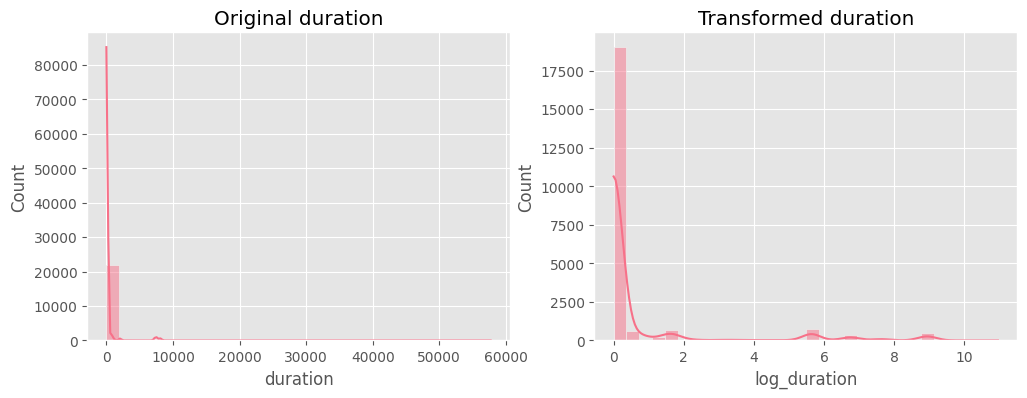

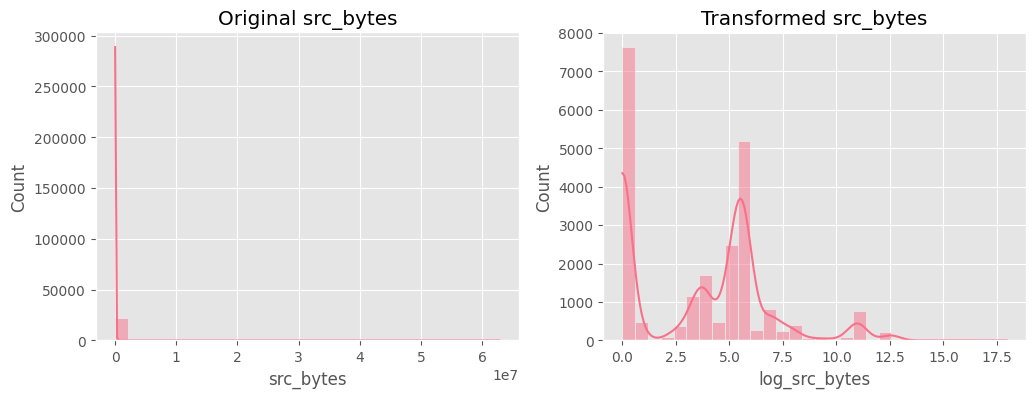

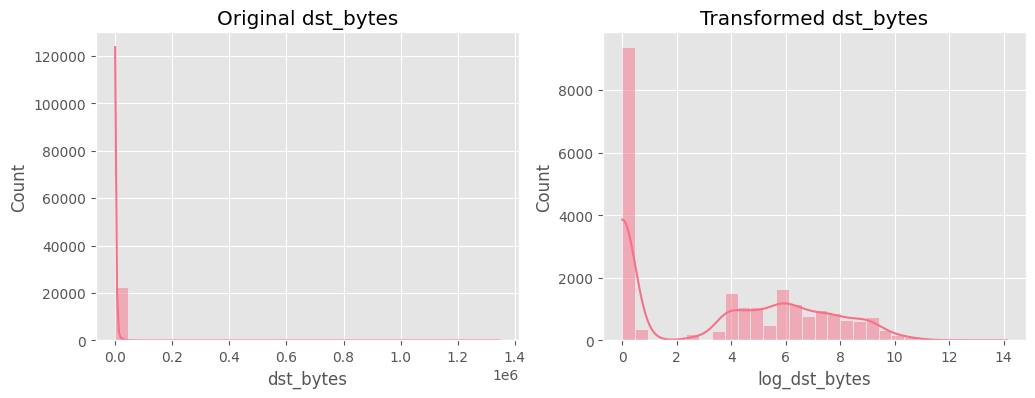

In [39]:
skewed_cols = ['duration','src_bytes','dst_bytes']

def apply_log_transform(df,cols):
    df_transform = df.copy()
    for col in cols:
        new_col = f"log_{col}"
        df_transform[new_col] = np.log1p(df_transform[col])

        plt.figure(figsize = (12,4))
        plt.subplot(1,2,1)
        sns.histplot(df[col],bins = 30, kde=True)
        plt.title(f"Original {col}")

        plt.subplot(1,2,2)
        sns.histplot(df_transform[new_col],bins = 30, kde=True)
        plt.title(f"Transformed {col}")
        plt.show()
    return df_transform

df_train = apply_log_transform(df_train,skewed_cols)
df_test = apply_log_transform(df_test,skewed_cols)

In [40]:

def engineer_features(df):
    df_eng = df.copy()
    
    # 1. Total Bytes
    df_eng['total_bytes'] = df_eng['src_bytes'] + df_eng['dst_bytes']
    
    # 2. Byte Ratio (Handle division by zero)
    df_eng['src_bytes_ratio'] = df_eng['src_bytes'] / (df_eng['total_bytes'] + 1e-5)
    
    # 3. Load / Packet Rate
    # If duration is 0, we assume it's a single instantaneous event (rate = count)
    df_eng['packet_rate'] = df_eng['count'] / (df_eng['duration'] + 1e-5)
    
    # 4. Title: Flow Asymmetry
    df_eng['byte_diff'] = abs(df_eng['src_bytes'] - df_eng['dst_bytes'])
    
    # 5. Flag interactions (example: is it an error flag?)
    error_flags = ['S0', 'S1', 'S2', 'S3', 'REJ']
    df_eng['is_error_flag'] = df_eng['flag'].isin(error_flags).astype(int)
    
    # 6. Critical Host Interaction
    # Interaction between 'same_srv_rate' and 'dst_host_same_srv_rate'
    df_eng['same_srv_interaction'] = df_eng['same_srv_rate'] * df_eng['dst_host_same_srv_rate']
    
    return df_eng

df_train = engineer_features(df_train)
df_test = engineer_features(df_test)

print("New Feature Set Head:")
print(df_train[['src_bytes_ratio', 'packet_rate', 'is_error_flag', 'same_srv_interaction']].head())


New Feature Set Head:
   src_bytes_ratio  packet_rate  is_error_flag  same_srv_interaction
0         1.000000     200000.0              0                 0.170
1         1.000000    1300000.0              0                 0.000
2         0.000000   12300000.0              1                 0.005
3         0.027668     500000.0              0                 1.000
4         0.321486    3000000.0              0                 1.000


In [41]:
df_train['service']

0         ftp_data
1            other
2          private
3             http
4             http
            ...   
125968     private
125969     private
125970        smtp
125971      klogin
125972    ftp_data
Name: service, Length: 125973, dtype: object

In [42]:
ohe = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
cols_to_encode = ['protocol_type','flag']

#Fit and Train

ohe_train = pd.DataFrame(ohe.fit_transform(df_train[cols_to_encode]))
ohe_train.columns = ohe.get_feature_names_out(cols_to_encode)
ohe_train.index = df_train.index
# ohe_train.index

#Transform Test

ohe_test = pd.DataFrame(ohe.transform(df_test[cols_to_encode]))
ohe_test.columns = ohe.get_feature_names_out(cols_to_encode)
ohe_test.index = df_test.index

service_freq = df_train['service'].value_counts(normalize = True)
df_train['service_freq'] = df_train['service'].map(service_freq)
df_test['service_freq'] = df_test['service'].map(service_freq).fillna(0)

df_train_encode = pd.concat([df_train,ohe_train],axis = 1)
df_test_encode = pd.concat([df_test,ohe_test],axis = 1)

df_train_encode.columns
# df_train_encode

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_dif

In [43]:
print(df_train_encode.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty_level', 'attack_class',
       'is_outlier', 'log_duration', 'log_src_bytes', 'log_dst_bytes',
       'total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_dif

In [44]:
df_test_encode

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,tcp,private,REJ,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,tcp,http,SF,317,938,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [45]:
df_train_encode.drop(columns=['protocol_type','flag','service'],inplace = True)
df_test_encode.drop(columns=['protocol_type','flag','service'],inplace = True)

In [46]:
print(df_train_encode.shape)

df_test_encode

(125973, 66)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,12983,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,20,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1,0,15,0,0,0,0,0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,794,333,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22540,0,317,938,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22541,0,54540,8314,0,0,0,2,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22542,0,42,42,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [47]:
df_train_encode



,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
125969,8,105,145,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125970,0,2231,384,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125971,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [48]:
corr_matrix = df_train_encode.select_dtypes(include=[np.number]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column]>0.95)]
print(f"Features to drop due to high corelation (>0.95): {to_drop}")

df_train_reduce = df_train_encode.drop(columns=to_drop, errors='ignore')
df_test_reduce = df_test_encode.drop(columns=to_drop, errors='ignore')
print(f"Reduce Shape: {df_train_reduce.shape}")

Features to drop due to high corelation (>0.95): ['num_root', 'srv_serror_rate', 'srv_rerror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_srv_rerror_rate', 'packet_rate', 'byte_diff', 'same_srv_interaction', 'flag_S0']
Reduce Shape: (125973, 56)


In [49]:
d= df_train_encode[to_drop]
d.iloc[:10]

,num_root,srv_serror_rate,srv_rerror_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_srv_rerror_rate,packet_rate,byte_diff,same_srv_interaction,flag_S0
0,0,0.0,0.0,0.00,0.00,0.00,200000.0,491,0.1700,0.0
1,0,0.0,0.0,0.00,0.00,0.00,1300000.0,146,0.0000,0.0
2,0,1.0,0.0,1.00,1.00,0.00,12300000.0,0,0.0050,1.0
3,0,0.2,0.0,0.03,0.01,0.01,500000.0,7921,1.0000,0.0
4,0,0.0,0.0,0.00,0.00,0.00,3000000.0,221,1.0000,0.0
5,0,0.0,1.0,0.00,0.00,1.00,12100000.0,0,0.0112,0.0
6,0,1.0,0.0,1.00,1.00,0.00,16600000.0,0,0.0020,1.0
7,0,1.0,0.0,1.00,1.00,0.00,11700000.0,0,0.0084,1.0
8,0,1.0,0.0,1.00,1.00,0.00,27000000.0,0,0.0081,1.0
9,0,1.0,0.0,1.00,1.00,0.00,13300000.0,0,0.0030,1.0


In [50]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder, PowerTransformer

exclude_cols = ['label','attack_class','difficulty_level','is_outlier']
features_to_scale = [col for col in df_train_reduce.columns if col not in exclude_cols]

scaler = RobustScaler()

df_train_reduce[features_to_scale] = scaler.fit_transform(df_train_reduce[features_to_scale])
df_test_reduce[features_to_scale] = scaler.transform(df_test_reduce[features_to_scale])

print(df_train_reduce[features_to_scale[0:5]].describe())

           duration     src_bytes     dst_bytes           land  wrong_fragment
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   125973.000000
mean      287.14465  1.649375e+02  3.833162e+01       0.000198        0.022687
std      2604.51531  2.126932e+04  7.793157e+03       0.014086        0.253530
min         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
25%         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
50%         0.00000  0.000000e+00  0.000000e+00       0.000000        0.000000
75%         0.00000  8.405797e-01  1.000000e+00       0.000000        0.000000
max     42908.00000  4.999869e+06  2.538638e+06       1.000000        3.000000


In [51]:
df_train_reduce[features_to_scale[0:5]]

,duration,src_bytes,dst_bytes,land,wrong_fragment
0,0.0,1.619565,0.000000,0.0,0.0
1,0.0,0.369565,0.000000,0.0,0.0
2,0.0,-0.159420,0.000000,0.0,0.0
3,0.0,0.681159,15.800388,0.0,0.0
4,0.0,0.561594,0.813953,0.0,0.0
...,...,...,...,...,...
125968,0.0,-0.159420,0.000000,0.0,0.0
125969,8.0,0.221014,0.281008,0.0,0.0
125970,0.0,7.923913,0.744186,0.0,0.0
125971,0.0,-0.159420,0.000000,0.0,0.0


In [52]:
target_col = 'attack_class'
X = df_train_reduce.drop(columns=['label', 'attack_class', 'difficulty_level'])
y = df_train_reduce[target_col]

print("Before SMOTE:")
print(y.value_counts())

X = X.fillna(0)

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(k_neighbors=5, random_state=SEED)
    X_resampled, y_resampled = smote.fit_resample(X, y)
except Exception:
    class_counts = y.value_counts()
    max_count = class_counts.max()
    parts_x = []
    parts_y = []
    for cls in class_counts.index:
        x_cls = X[y == cls]
        y_cls = y[y == cls]
        idx = np.random.RandomState(SEED).choice(x_cls.index, size=max_count, replace=True)
        parts_x.append(x_cls.loc[idx])
        parts_y.append(y_cls.loc[idx])
    X_resampled = pd.concat(parts_x, axis=0).reset_index(drop=True)
    y_resampled = pd.concat(parts_y, axis=0).reset_index(drop=True)

print("\nAfter Resampling:")
print(y_resampled.value_counts())
y_resampled

Before SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

After Resampling:
attack_class
normal    67343
DoS       67343
Probe     67343
R2L       67343
U2R       67343
Name: count, dtype: int64


0         normal
1         normal
2         normal
3         normal
4         normal
           ...  
336710       U2R
336711       U2R
336712       U2R
336713       U2R
336714       U2R
Name: attack_class, Length: 336715, dtype: object

In [53]:
y_resampled


0         normal
1         normal
2         normal
3         normal
4         normal
           ...  
336710       U2R
336711       U2R
336712       U2R
336713       U2R
336714       U2R
Name: attack_class, Length: 336715, dtype: object

In [54]:
X_resampled

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,2570.0,0.373188,0.203488,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7.0,0.210145,2.794574,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.326087,19.691860,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.572464,4.060078,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,-0.039855,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336710,0.0,-0.159420,10.922481,0.0,0.0,0.0,0.0,0.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
336711,79.0,0.858696,2.521318,0.0,0.0,0.0,2.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
336712,7.0,0.673913,1.248062,0.0,0.0,0.0,4.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
336713,0.0,-0.159420,9.717054,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


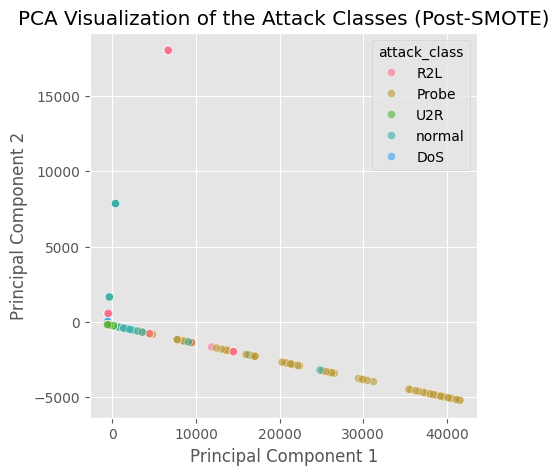

In [55]:
pca = PCA(n_components=2)
n_plot = min(5000, len(X_resampled))
idx = X_resampled.sample(n=n_plot, random_state=SEED).index
x_pca = pca.fit_transform(X_resampled.loc[idx])

plt.figure(figsize = (5,5))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=y_resampled.loc[idx], alpha=0.6)
plt.title("PCA Visualization of the Attack Classes (Post-SMOTE)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [60]:
df_final_train = pd.concat([X_resampled,y_resampled],axis=1)
output_dir = './data/processed/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
save_path = os.path.join(output_dir, 'train_processed_advanced.csv')
df_final_train.to_csv(save_path,index = False)
print(f"Saved the Data to {save_path}")

Saved the Data to ./data/processed/train_processed_advanced.csv


In [64]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

target_col = "attack_class"
X_train = df_train_reduce.drop(columns=["label", "attack_class", "difficulty_level"], errors="ignore").fillna(0)
y_train = df_train_reduce[target_col]

models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=250, max_depth=None, n_jobs=-1, class_weight="balanced_subsample", random_state=SEED
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "acc": scores["test_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "precision_macro": scores["test_precision_macro"].mean(),
        "recall_macro": scores["test_recall_macro"].mean()
    })

benchmark_df = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(benchmark_df.style.background_gradient(cmap="YlGn"))

,model,acc,f1_macro,precision_macro,recall_macro
1,RandomForest,0.998873,0.908764,0.970982,0.884418
0,LogReg,0.738031,0.489339,0.490187,0.779558


              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       1.00      0.97      0.98       199
         U2R       0.89      0.80      0.84        10
      normal       1.00      1.00      1.00     13469

    accuracy                           1.00     25195
   macro avg       0.98      0.95      0.96     25195
weighted avg       1.00      1.00      1.00     25195



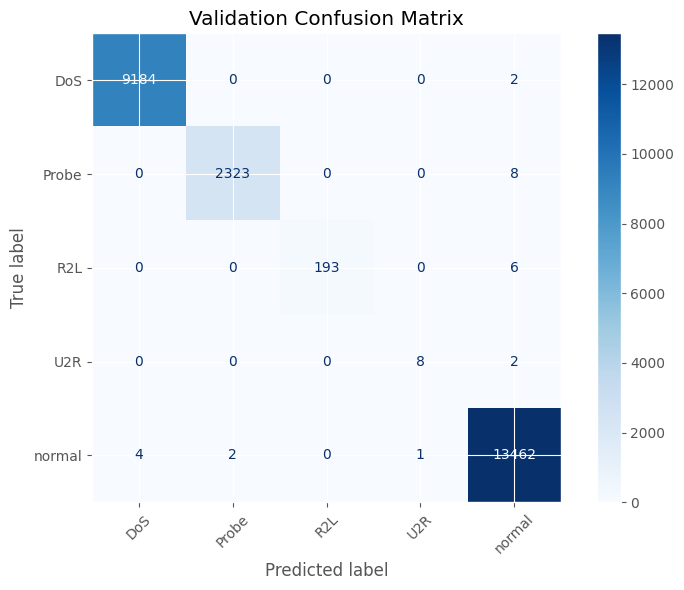

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

best_model = RandomForestClassifier(
    n_estimators=300, n_jobs=-1, class_weight="balanced_subsample", random_state=SEED
)
best_model.fit(X_tr, y_tr)
y_pred = best_model.predict(X_va)

print(classification_report(y_va, y_pred))
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_va, y_pred, xticks_rotation=45, cmap="Blues", ax=ax)
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()